# RetailPulse – RFM Customer Segmentation

## Objective

Identify meaningful customer segments using Recency,
Frequency, and Monetary (RFM) analysis.

## Business Questions

1. Who are our most valuable customers?
2. Which customers purchase frequently?
3. Which customers have not purchased recently?
4. Which customers generate the most revenue?
5. Which customers should be prioritized for retention?
6. How can customer segments support marketing decisions?

## Method

Customer Transactions
→ RFM Metrics
→ RFM Scores
→ K-Means Clustering
→ Business Interpretation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Customer Data

In [2]:
CLEANED_DIR = Path("../data/cleaned")

customer = pd.read_csv(
    CLEANED_DIR / "retail_customer_analysis.csv"
)

print("Customer dataset loaded.")
print("Shape:", customer.shape)

Customer dataset loaded.
Shape: (779425, 17)


## Convert Date

In [3]:
customer["InvoiceDate"] = pd.to_datetime(
    customer["InvoiceDate"],
    errors="coerce"
)

print(customer["InvoiceDate"].dtype)

datetime64[ns]


In [4]:
customer.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,TransactionType,Revenue,Year,Month,MonthName,Day,DayName,Week,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,Sale,83.4,2009,12,December,1,Tuesday,49,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Sale,81.0,2009,12,December,1,Tuesday,49,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Sale,81.0,2009,12,December,1,Tuesday,49,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,Sale,100.8,2009,12,December,1,Tuesday,49,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,Sale,30.0,2009,12,December,1,Tuesday,49,7


In [5]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Invoice          779425 non-null  int64         
 1   StockCode        779425 non-null  object        
 2   Description      779425 non-null  object        
 3   Quantity         779425 non-null  int64         
 4   InvoiceDate      779425 non-null  datetime64[ns]
 5   Price            779425 non-null  float64       
 6   Customer_ID      779425 non-null  int64         
 7   Country          779425 non-null  object        
 8   TransactionType  779425 non-null  object        
 9   Revenue          779425 non-null  float64       
 10  Year             779425 non-null  int64         
 11  Month            779425 non-null  int64         
 12  MonthName        779425 non-null  object        
 13  Day              779425 non-null  int64         
 14  DayName          779

In [6]:
customer.isnull().sum()

Invoice            0
StockCode          0
Description        0
Quantity           0
InvoiceDate        0
Price              0
Customer_ID        0
Country            0
TransactionType    0
Revenue            0
Year               0
Month              0
MonthName          0
Day                0
DayName            0
Week               0
Hour               0
dtype: int64

We expect CustomerID to have no missing values because this dataset was specifically created from records with identifiable customers.

## Understand the observation period

In [7]:
print(
    "First transaction:",
    customer["InvoiceDate"].min()
)

print(
    "Last transaction:",
    customer["InvoiceDate"].max()
)

First transaction: 2009-12-01 07:45:00
Last transaction: 2011-12-09 12:50:00


## Create reference date

In [9]:
reference_date = (
    customer["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

print("Reference date:", reference_date)

Reference date: 2011-12-10 12:50:00


# Calculate RFM

In [12]:
rfm = (
    customer
    .groupby("Customer_ID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (
                reference_date - x.max()
            ).days
        ),
        
        Frequency=(
            "Invoice",
            "nunique"
        ),
        
        Monetary=(
            "Revenue",
            "sum"
        )
    )
    .reset_index()
)

In [13]:
rfm.head()

,Customer_ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


In [14]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer_ID  5878 non-null   int64  
 1   Recency      5878 non-null   int64  
 2   Frequency    5878 non-null   int64  
 3   Monetary     5878 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 183.8 KB


In [15]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_ID,5878.0,15315.313542,1715.572666,12346.00,13833.25,15314.50,16797.750,18287.00
Recency,5878.0,201.331916,209.338707,1.00,26.00,96.00,380.000,739.00
Frequency,5878.0,6.289384,13.009406,1.00,1.00,3.00,7.000,398.00
Monetary,5878.0,2955.904095,14440.852688,2.95,342.28,867.74,2248.305,580987.04


## Check for invalid RFM values

In [16]:
print("Negative Recency:", (rfm["Recency"] < 0).sum())
print("Zero Frequency:", (rfm["Frequency"] <= 0).sum())
print("Negative Monetary:", (rfm["Monetary"] < 0).sum())

Negative Recency: 0
Zero Frequency: 0
Negative Monetary: 0


## RFM distributions

# Recency

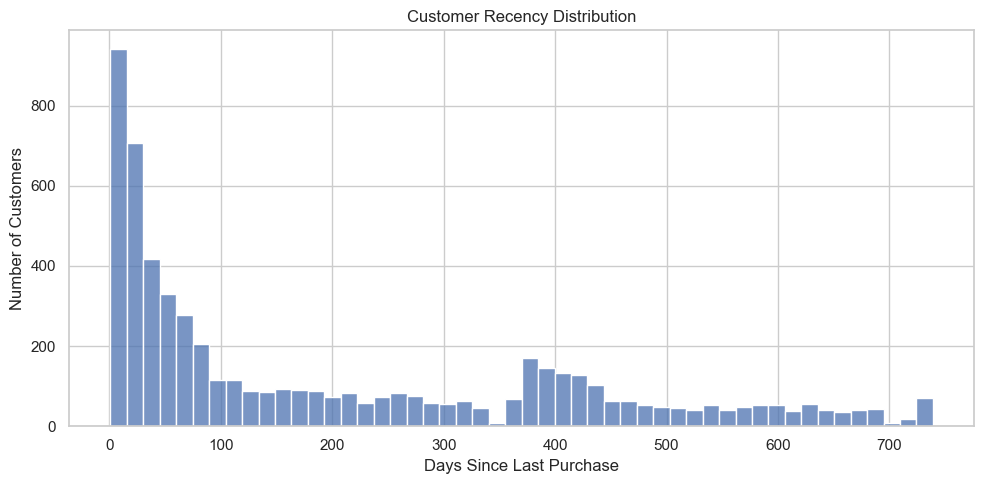

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(
    rfm["Recency"],
    bins=50
)

plt.title("Customer Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

# Frequency

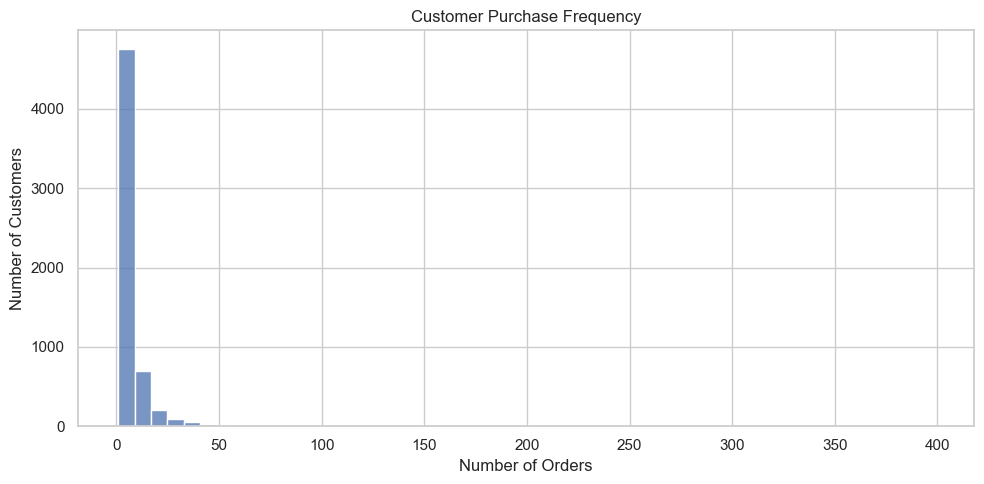

In [18]:
plt.figure(figsize=(10, 5))

sns.histplot(
    rfm["Frequency"],
    bins=50
)

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

# Monetary

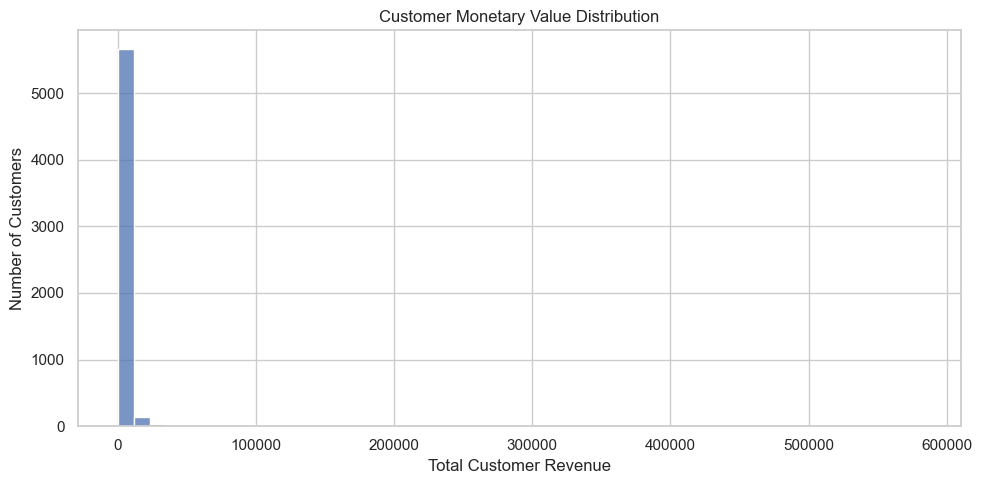

In [19]:
plt.figure(figsize=(10, 5))

sns.histplot(
    rfm["Monetary"],
    bins=50
)

plt.title("Customer Monetary Value Distribution")
plt.xlabel("Total Customer Revenue")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

# RFM correlation

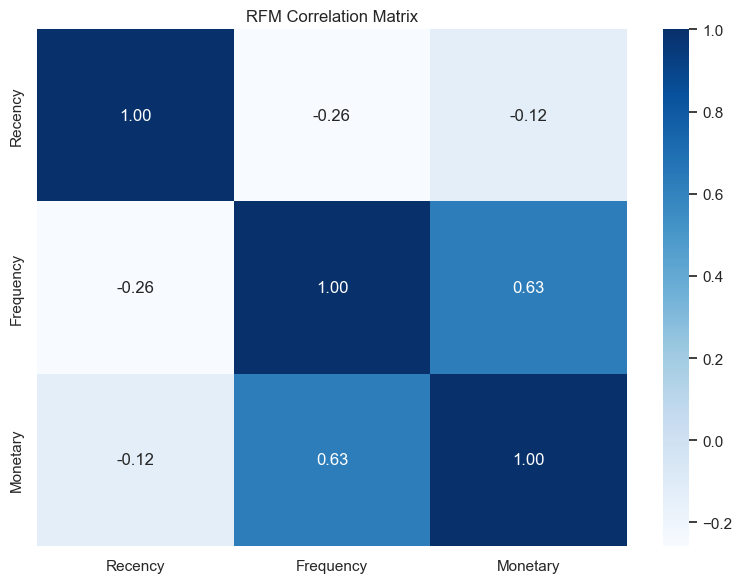

In [20]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    rfm[
        ["Recency", "Frequency", "Monetary"]
    ].corr(),
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("RFM Correlation Matrix")

plt.tight_layout()
plt.show()

# RFM scoring

In [21]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
)

In [22]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [23]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

## Convert scores to integers

In [24]:
rfm["R_Score"] = rfm["R_Score"].astype(int)

rfm["F_Score"] = rfm["F_Score"].astype(int)

rfm["M_Score"] = rfm["M_Score"].astype(int)

# Create combined RFM score

In [25]:
rfm["RFM_Score"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

In [27]:
rfm[
    [
        "Customer_ID",
        "Recency",
        "Frequency",
        "Monetary",
        "R_Score",
        "F_Score",
        "M_Score",
        "RFM_Score"
    ]
].head(20)

,Customer_ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,12,77556.46,2,5,5,12
1,12347,2,8,4921.53,5,4,5,14
2,12348,75,5,2019.40,3,4,4,11
3,12349,19,4,4428.69,5,3,5,13
4,12350,310,1,334.40,2,1,2,5
5,12351,375,1,300.93,2,1,2,5
6,12352,36,10,2849.84,4,5,4,13
7,12353,204,2,406.76,2,2,2,6
8,12354,232,1,1079.40,2,1,3,6
9,12355,214,2,947.61,2,2,3,7


## Top customers

In [28]:
top_customers = (
    rfm
    .sort_values(
        "RFM_Score",
        ascending=False
    )
    .head(20)
)

top_customers

,Customer_ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
2587,14963,10,12,3123.57,5,5,5,15
5862,18272,3,9,4385.98,5,5,5,15
16,12362,3,11,5356.23,5,5,5,15
2585,14961,11,22,16410.15,5,5,5,15
2629,15005,16,56,13754.58,5,5,5,15
5831,18241,10,21,2986.99,5,5,5,15
5820,18230,9,9,4291.06,5,5,5,15
5835,18245,7,20,6324.98,5,5,5,15
5819,18229,12,28,10150.51,5,5,5,15
2685,15061,4,127,126389.02,5,5,5,15


## Champions

In [29]:
rfm["Segment"] = "Other"

rfm.loc[
    (
        (rfm["R_Score"] >= 4) &
        (rfm["F_Score"] >= 4) &
        (rfm["M_Score"] >= 4)
    ),
    "Segment"
] = "Champions"

In [30]:
rfm["Segment"].value_counts()

Segment
Other        4581
Champions    1297
Name: count, dtype: int64

# Loyal Customers

In [32]:
rfm.loc[
    (
        (rfm["F_Score"] >= 4) &
        (rfm["R_Score"] >= 3)
    ) &
    (rfm["Segment"] == "Other"),
    "Segment"
] = "Loyal Customers"

## High Value Customers

In [34]:
rfm.loc[
    (
        (rfm["M_Score"] >= 4) &
        (rfm["R_Score"] >= 3)
    ) &
    (rfm["Segment"] == "Other"),
    "Segment"
] = "High Value Customers"

## At Risk Customers

In [36]:
rfm.loc[
    (
        (rfm["R_Score"] <= 2) &
        (rfm["F_Score"] >= 3)
    ) &
    (rfm["Segment"] == "Other"),
    "Segment"
] = "At Risk"

## New / Potential Customers

In [37]:
rfm.loc[
    (
        (rfm["R_Score"] >= 4) &
        (rfm["F_Score"] <= 2)
    ) &
    (rfm["Segment"] == "Other"),
    "Segment"
] = "New / Potential"

## View segments

In [39]:
segment_summary = (
    rfm
    .groupby("Segment")
    .agg(
        Customers=("Customer_ID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Total_Revenue=("Monetary", "sum"),
        Avg_Revenue=("Monetary", "mean")
    )
    .reset_index()
)

segment_summary

,Segment,Customers,Avg_Recency,Avg_Frequency,Total_Revenue,Avg_Revenue
0,At Risk,824,369.100728,4.940534,1.589384e+06,1928.864456
1,Champions,1297,19.961449,17.105628,1.185959e+07,9143.863913
2,High Value Customers,255,60.364706,3.050980,7.571579e+05,2969.246518
3,Loyal Customers,701,84.368046,7.736091,1.856667e+06,2648.597753
4,New / Potential,417,28.503597,1.436451,1.760136e+05,422.095060
5,Other,2384,321.719379,1.640940,1.135990e+06,476.505845


In [40]:
segment_summary[
    [
        "Avg_Recency",
        "Avg_Frequency",
        "Total_Revenue",
        "Avg_Revenue"
    ]
] = segment_summary[
    [
        "Avg_Recency",
        "Avg_Frequency",
        "Total_Revenue",
        "Avg_Revenue"
    ]
].round(2)

## Segment distribution

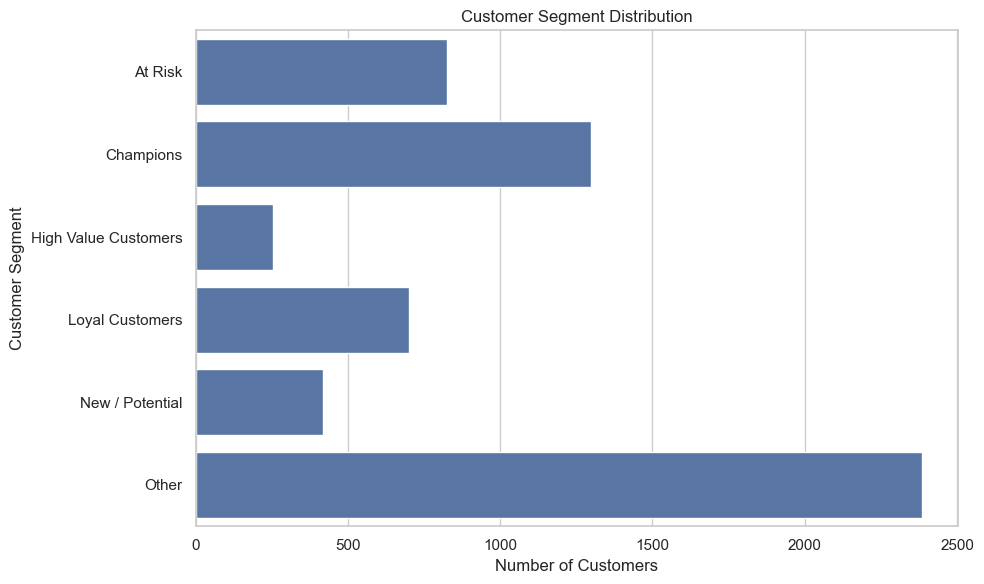

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_summary,
    x="Customers",
    y="Segment"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

## Revenue by segment

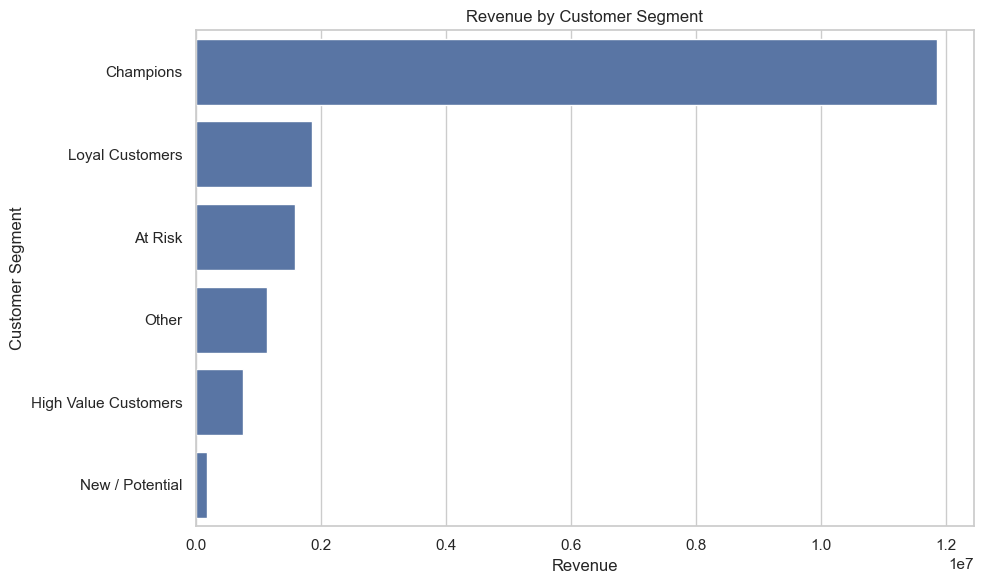

In [42]:
segment_revenue = (
    segment_summary
    .sort_values(
        "Total_Revenue",
        ascending=False
    )
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_revenue,
    x="Total_Revenue",
    y="Segment"
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Revenue")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

# K-Means preparation

In [43]:
rfm_features = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
].copy()

## Handle skewness

In [44]:
rfm_log = np.log1p(
    rfm_features
)

In [45]:
rfm_log.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,4.454132,1.549588,6.816979
std,1.559404,0.809447,1.385486
min,0.693147,0.693147,1.373716
25%,3.295837,0.693147,5.838546
50%,4.574711,1.386294,6.767044
75%,5.942799,2.079442,7.718377
max,6.606650,5.988961,13.272485


## Standardize

In [46]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_log
)

## Find suitable K

In [47]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(rfm_scaled)
    
    inertia.append(
        model.inertia_
    )

## Elbow curve

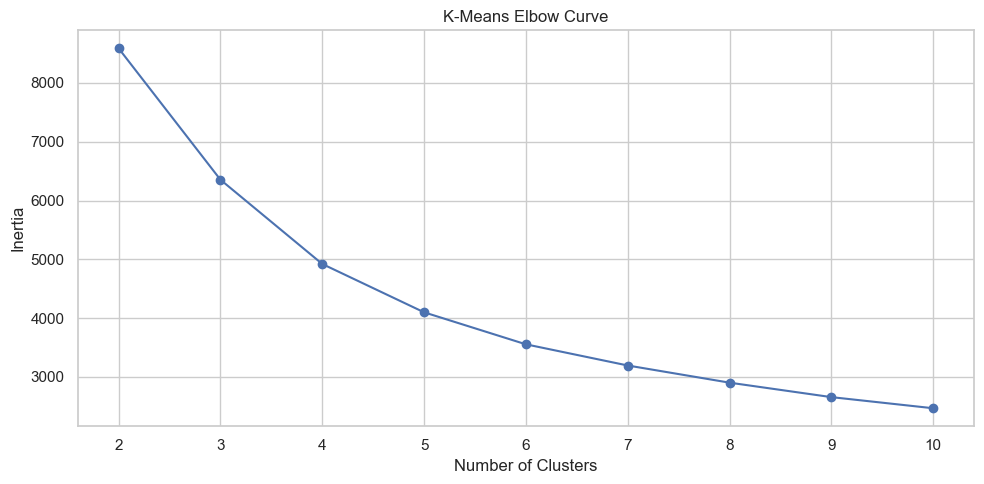

In [48]:
plt.figure(figsize=(10, 5))

plt.plot(
    list(K_range),
    inertia,
    marker="o"
)

plt.title("K-Means Elbow Curve")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.tight_layout()
plt.show()

## Silhouette analysis

In [49]:
silhouette_scores = []

for k in K_range:
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(
        rfm_scaled
    )
    
    score = silhouette_score(
        rfm_scaled,
        labels
    )
    
    silhouette_scores.append(score)

In [50]:
silhouette_results = pd.DataFrame({
    "Clusters": list(K_range),
    "Silhouette_Score": silhouette_scores
})

silhouette_results

,Clusters,Silhouette_Score
0,2,0.438602
1,3,0.347745
2,4,0.364971
3,5,0.342496
4,6,0.334796
5,7,0.306636
6,8,0.303315
7,9,0.292524
8,10,0.290525


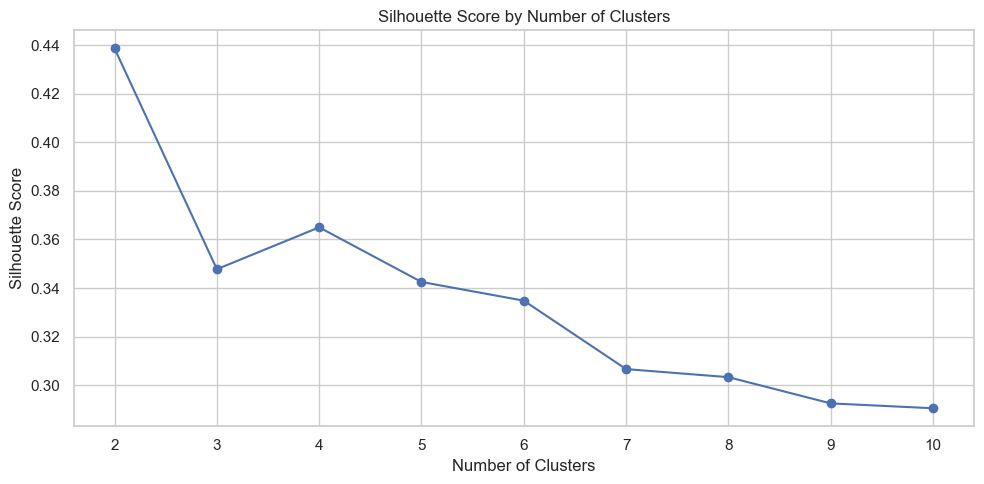

In [51]:
plt.figure(figsize=(10, 5))

plt.plot(
    silhouette_results["Clusters"],
    silhouette_results["Silhouette_Score"],
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

## Select K

In [52]:
best_k = silhouette_results.loc[
    silhouette_results["Silhouette_Score"].idxmax(),
    "Clusters"
]

print("Recommended number of clusters:", best_k)

Recommended number of clusters: 2


## Train final K-Means

In [53]:
kmeans = KMeans(
    n_clusters=int(best_k),
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(
    rfm_scaled
)

## Cluster summary

In [55]:
cluster_summary = (
    rfm
    .groupby("Cluster")
    .agg(
        Customers=("Customer_ID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum")
    )
    .reset_index()
)

cluster_summary.round(2)

,Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
0,0,3558,299.65,2.10,614.34,2185833.06
1,1,2320,50.56,12.72,6546.97,15188971.20


# Business interpretation

In [56]:
cluster_summary = cluster_summary.sort_values(
    "Avg_Monetary",
    ascending=False
).reset_index(drop=True)

cluster_summary

,Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
0,1,2320,50.555603,12.717672,6546.970346,1.518897e+07
1,0,3558,299.645868,2.097808,614.343189,2.185833e+06


## Save RFM dataset

In [57]:
rfm.to_csv(
    CLEANED_DIR / "customer_rfm_segments.csv",
    index=False
)

print("RFM segmentation dataset saved.")

RFM segmentation dataset saved.


## Save segment summary

In [58]:
segment_summary.to_csv(
    CLEANED_DIR / "customer_segment_summary.csv",
    index=False
)

cluster_summary.to_csv(
    CLEANED_DIR / "customer_cluster_summary.csv",
    index=False
)

print("Segmentation summaries saved.")

Segmentation summaries saved.


In [59]:
cluster_summary

,Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
0,1,2320,50.555603,12.717672,6546.970346,1.518897e+07
1,0,3558,299.645868,2.097808,614.343189,2.185833e+06


In [60]:
segment_summary

,Segment,Customers,Avg_Recency,Avg_Frequency,Total_Revenue,Avg_Revenue
0,At Risk,824,369.10,4.94,1589384.31,1928.86
1,Champions,1297,19.96,17.11,11859591.50,9143.86
2,High Value Customers,255,60.36,3.05,757157.86,2969.25
3,Loyal Customers,701,84.37,7.74,1856667.02,2648.60
4,New / Potential,417,28.50,1.44,176013.64,422.10
5,Other,2384,321.72,1.64,1135989.93,476.51
